In [3]:
# импорт необходимых библиотек
import numpy as np
import pandas as pd
import re
import nltk
import string
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
# читаем данные из CSV-файла
df = pd.read_csv('reviews.csv', encoding='utf-8', sep='\t')
df.head() # вывод первых 5 строк из датафрейма

,review,sentiment
0,качество плохое пошив ужасный (горловина напер...,negative
1,"Товар отдали другому человеку, я не получила п...",negative
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative
3,"товар не пришел, продавец продлил защиту без м...",negative
4,"Кофточка голая синтетика, носить не возможно.",negative


In [9]:
# предобработка датасета
df['cleaned_reviews'] = df['review'].str.lower() # приведение к нижнему регистру
df['cleaned_reviews'] = df['cleaned_reviews'].str.replace(r'[^\w\s]','', regex=True) # удаление пунктуации
df['cleaned_reviews'] = df['cleaned_reviews'].str.replace(r'\d+', '', regex=True) # удаление чисел

df.head()

,review,sentiment,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,negative,качество плохое пошив ужасный горловина напере...
1,"Товар отдали другому человеку, я не получила п...",negative,товар отдали другому человеку я не получила по...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая ничего общего с предс...
3,"товар не пришел, продавец продлил защиту без м...",negative,товар не пришел продавец продлил защиту без мо...
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить не возможно


In [10]:
# удаление стоп-слов
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('russian'))
def stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])
df["cleaned_reviews"] = df["cleaned_reviews"].apply(stopwords)

In [11]:
# определние самых частотных слов
from collections import Counter
cnt = Counter()
for text in df["cleaned_reviews"].values:
    for word in text.split():
        cnt[word] += 1
        
cnt.most_common(20)
# удаление самых частотных слов
freq = set([w for (w, wc) in cnt.most_common(10)])
# функция удаления слов
def freqwords(text):
    return " ".join([word for word in str(text).split() if word not 
in freq])
# применение функции
df["cleaned_reviews"] = df["cleaned_reviews"].apply(freqwords)
df.head()

,review,sentiment,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,negative,плохое пошив ужасный горловина наперекос фото ...
1,"Товар отдали другому человеку, я не получила п...",negative,отдали другому человеку получила посылку ладно...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...
3,"товар не пришел, продавец продлил защиту без м...",negative,пришел продлил защиту моего согласия продавца ...
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно


In [12]:
# удаление низкочастотных слов
freq = pd.Series(' '.join(df['cleaned_reviews']).split()).value_counts()[-10:]
freq = list(freq.index)
df['cleaned_reviews'] = df['cleaned_reviews'].apply(lambda x: " ".join(x for x in x.split() if x not in freq))
df.head()

,review,sentiment,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,negative,плохое пошив ужасный горловина наперекос фото ...
1,"Товар отдали другому человеку, я не получила п...",negative,отдали другому человеку получила посылку ладно...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...
3,"товар не пришел, продавец продлил защиту без м...",negative,пришел продлил защиту моего согласия продавца ...
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно


In [13]:
# удаление эмодзи
def emoji(string):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', string)
#passing the emoji function to 'text_rare'
df['cleaned_reviews'] = df['cleaned_reviews'].apply(emoji)
df.head()

,review,sentiment,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,negative,плохое пошив ужасный горловина наперекос фото ...
1,"Товар отдали другому человеку, я не получила п...",negative,отдали другому человеку получила посылку ладно...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...
3,"товар не пришел, продавец продлил защиту без м...",negative,пришел продлил защиту моего согласия продавца ...
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно


In [14]:
# удалениe URL
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)
df['cleaned_reviews'] = df['cleaned_reviews'].apply(remove_urls)
df.head()

,review,sentiment,cleaned_reviews
0,качество плохое пошив ужасный (горловина напер...,negative,плохое пошив ужасный горловина наперекос фото ...
1,"Товар отдали другому человеку, я не получила п...",negative,отдали другому человеку получила посылку ладно...
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...
3,"товар не пришел, продавец продлил защиту без м...",negative,пришел продлил защиту моего согласия продавца ...
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно


In [15]:
# токенизация предобработанного текста
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

def tokenize_text(text):
    return nltk.word_tokenize(text)

# сохраним токены (списки слов) в отдельной колонке tokenized_text
df['tokenized_text'] = df['cleaned_reviews'].apply(tokenize_text)
df.head()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,review,sentiment,cleaned_reviews,tokenized_text
0,качество плохое пошив ужасный (горловина напер...,negative,плохое пошив ужасный горловина наперекос фото ...,"[плохое, пошив, ужасный, горловина, наперекос,..."
1,"Товар отдали другому человеку, я не получила п...",negative,отдали другому человеку получила посылку ладно...,"[отдали, другому, человеку, получила, посылку,..."
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...,"[ужасная, синтетика, тонкая, общего, представл..."
3,"товар не пришел, продавец продлил защиту без м...",negative,пришел продлил защиту моего согласия продавца ...,"[пришел, продлил, защиту, моего, согласия, про..."
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно,"[кофточка, голая, синтетика, носить, возможно]"


In [19]:
# лемматизация текста
import pymorphy3
morph = pymorphy3.MorphAnalyzer()

# функция для лемматизации списка токенов
def lemmatize_tokens(tokens):
    if not isinstance(tokens, list):
        return tokens
    return [morph.parse(word)[0].normal_form for word in tokens]

# запишем результат в новый столбец lemmatized_text
df['lemmatized_text'] = df['tokenized_text'].apply(lemmatize_tokens)
df.head()

,review,sentiment,cleaned_reviews,tokenized_text,lemmatized_text
0,качество плохое пошив ужасный (горловина напер...,negative,плохое пошив ужасный горловина наперекос фото ...,"[плохое, пошив, ужасный, горловина, наперекос,...","[плохой, пошив, ужасный, горловина, наперекос,..."
1,"Товар отдали другому человеку, я не получила п...",negative,отдали другому человеку получила посылку ладно...,"[отдали, другому, человеку, получила, посылку,...","[отдать, другой, человек, получить, посылка, л..."
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...,"[ужасная, синтетика, тонкая, общего, представл...","[ужасный, синтетик, тонкий, общий, представить..."
3,"товар не пришел, продавец продлил защиту без м...",negative,пришел продлил защиту моего согласия продавца ...,"[пришел, продлил, защиту, моего, согласия, про...","[прийти, продлить, защита, мой, согласие, прод..."
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно,"[кофточка, голая, синтетика, носить, возможно]","[кофточка, голый, синтетик, носить, возможно]"


ВИЗУАЛЬНЫЙ АНАЛИЗ ОТЗЫВОВ

sentiment
negative    30000
neautral    30000
positive    30000
Name: count, dtype: int64


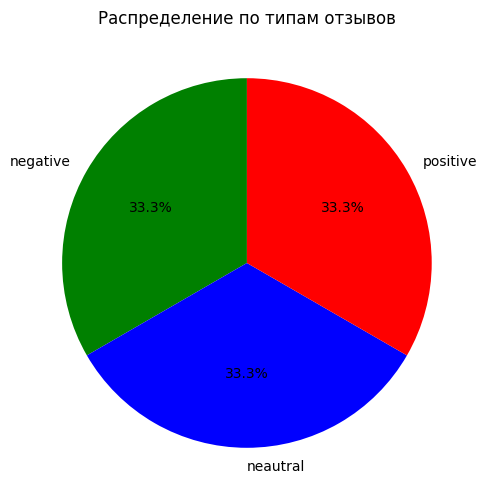

In [28]:
# 1. распределение по типам отзывов

# считаем количество отзывов каждого типа
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

# строим диаграмму
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
colors=['green', 'blue', 'red']
plt.pie(sentiment_counts,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90)
plt.title('Распределение по типам отзывов')
plt.show()

Вывод: отзывы в датасете распределены равномерно.

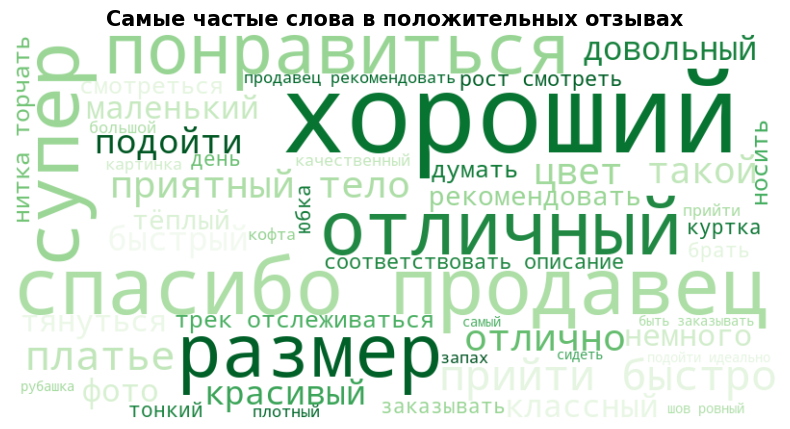

In [ ]:
# 2.1 Облако слов для положительных отзывов
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Фильтруем только положительные отзывы
positive_words = df[df['sentiment'] == 'positive']['lemmatized_text'].astype(str)

# 2. Объединяем все слова в одну строку
text = " ".join(review for review in positive_words)
text = text.replace("'", "").replace(",", "")

# 3. Настраиваем и генерируем облако
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='Greens',
    max_words=50
).generate(text)

# 4. Визуализация
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") # убираем оси
plt.title('Самые частые слова в положительных отзывах',
          fontsize=15, 
          fontweight='bold')
plt.show()



Вывод: довольные покупатели наиболее часто выражают благодарность продавцу словами "хороший", "отличный", "спасибо" и "понравиться". Также, выделяется слово "размер" - покупателям важно, чтобы вещь соответствовала заявленной размерной сетке. В положительных отзвывах пользователи наиболее часто отмечают качество товара ("цвет", "ткань", "приятный", "красивый"), а торчащие нитки не считают сущетсвенным минусом.

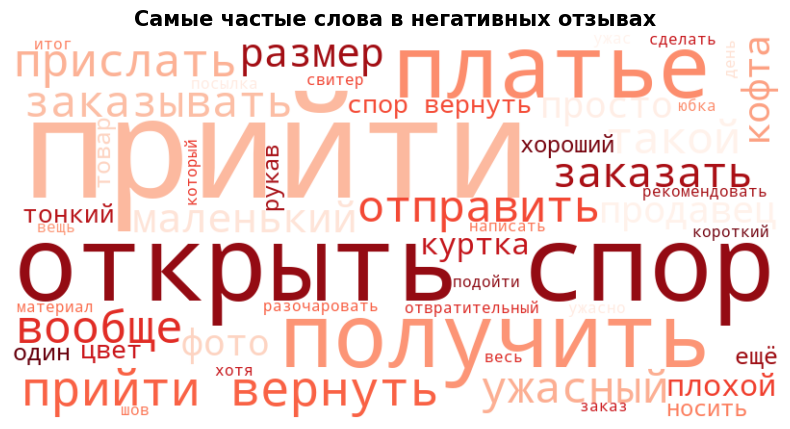

In [41]:
# 2.2 Облако слов для негативных отзывов

# 1. Фильтруем негативные отзывы
negative_words = df[df['sentiment'] == 'negative']['lemmatized_text']

# 2. Собираем текст
neg_text = " ".join(" ".join(review) for review in negative_words)
# внутренний " ".join(review) трансформирует список слов из одного отзыва в предложение
# внешний " ".join() собирает предложения в текст для облака слов
neg_text = neg_text.replace("'", "").replace(",", "")

# 3. Генерируем облако слов
wordcloud_neg = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='Reds',
    max_words=50
).generate(neg_text)

# 4. Визуализация
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis("off")
plt.title('Самые частые слова в негативных отзывах', 
          fontsize=15,
          fontweight='bold')
plt.show()


Вывод: недовольные покупатели склонны предъявлять претензии к продавцу с целью возврата средств ("открыть спор", "вернуть"). Также, пользователи часто жалуются на проблемы с доставкой - слова "прийти", "получить" и "отправить" достаточно крупные в облаке. В отличие от облака слов в положительных отзывах, здесь слово "размер" указывает на несоответствие вещи размерной сетке. Прилагательные "ужасный", "плохой", "отвратительный" задают эмоциональную окраску отрицательного отзыва.

In [42]:
# Добавим в датасет случайно сгенерированные даты, время и рейтинг отзывов для дальнейшего анализа

#рандомизаторы
import random
from datetime import datetime, timedelta
def rndate():
  start_date = datetime(2024, 1, 1)
  end_date = datetime(2025, 1, 1)
  # 2. Вычислите общее количество дней в диапазоне
  days_in_range = (end_date - start_date).days
  # 3. Сгенерируйте случайное количество дней в диапазоне
  random_days = random.randint(0, days_in_range)
  # 4. Создайте случайную дату, добавив случайное число дней к начальной дате
  random_date = start_date + timedelta(days=random_days)
  # 5. Теперь random_date содержит случайную дату, которую можно вставить в колонку
  return(random_date)

def rndrate_pos():
  random_rate = random.randint(4, 5)
  return(random_rate)

def rndrate_neg():
  random_rate = random.randint(1, 2)
  return(random_rate)
def rndrate_net():
  random_rate = random.randint(3, 4)
  return(random_rate)

from datetime import time
def generate_random_time():
    hour = random.randint(0, 23)
    minute = random.randint(0, 59)
    second = random.randint(0, 59)
    return time(hour, minute, second)

In [43]:
from datetime import datetime, timedelta
import random

def rndatetime():
    # Генерация случайной даты
    start_date = datetime(2024, 1, 1)
    end_date = datetime(2025, 1, 1)
    days_in_range = (end_date - start_date).days
    random_days = random.randint(0, days_in_range)
    random_date = start_date + timedelta(days=random_days)

    # Генерация случайного времени
    random_hour = random.randint(0, 23)
    random_minute = random.randint(0, 59)
    random_second = random.randint(0, 59)

    # Объединяем дату и время
    random_datetime = random_date.replace(hour=random_hour, minute=random_minute, second=random_second)

    return random_datetime

In [50]:
df['data'] = None
for i in range(len(df['sentiment'])):
  df.loc[i,'data'] = rndatetime()
  i=+1

df['rating'] = None
for i in range(len(df['sentiment'])):
  if df['sentiment'][i]=='positive':
    df.loc[i,'rating'] = rndrate_pos()
  elif df['sentiment'][i]=='negative':
    df.loc[i,'rating'] = rndrate_neg()
  else:
    df.loc[i,'rating'] = rndrate_net()

df.head()

,review,sentiment,cleaned_reviews,tokenized_text,lemmatized_text,data,rating,date,month,day_of_week,hour,day_of_week_num
0,качество плохое пошив ужасный (горловина напер...,negative,плохое пошив ужасный горловина наперекос фото ...,"[плохое, пошив, ужасный, горловина, наперекос,...","[плохой, пошив, ужасный, горловина, наперекос,...",2024-06-11 09:47:25,2,2024-04-18,4,Thursday,7,3
1,"Товар отдали другому человеку, я не получила п...",negative,отдали другому человеку получила посылку ладно...,"[отдали, другому, человеку, получила, посылку,...","[отдать, другой, человек, получить, посылка, л...",2024-04-29 15:00:41,2,2024-01-20,1,Saturday,21,5
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...,"[ужасная, синтетика, тонкая, общего, представл...","[ужасный, синтетик, тонкий, общий, представить...",2024-01-15 14:16:00,2,2024-01-08,1,Monday,21,0
3,"товар не пришел, продавец продлил защиту без м...",negative,пришел продлил защиту моего согласия продавца ...,"[пришел, продлил, защиту, моего, согласия, про...","[прийти, продлить, защита, мой, согласие, прод...",2024-03-11 18:24:15,2,2024-08-15,8,Thursday,16,3
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно,"[кофточка, голая, синтетика, носить, возможно]","[кофточка, голый, синтетик, носить, возможно]",2024-03-08 08:49:05,1,2024-04-06,4,Saturday,17,5


In [47]:
# Преобразуем колонку data в datetime и извлекаем компоненты времени
df['data'] = pd.to_datetime(df['data'])
df['date'] = df['data'].dt.date
df['month'] = df['data'].dt.month
df['day_of_week'] = df['data'].dt.day_name()
df['hour'] = df['data'].dt.hour
df['day_of_week_num'] = df['data'].dt.dayofweek  # для правильной сортировки
df.head()

,review,sentiment,cleaned_reviews,tokenized_text,lemmatized_text,data,rating,date,month,day_of_week,hour,day_of_week_num
0,качество плохое пошив ужасный (горловина напер...,negative,плохое пошив ужасный горловина наперекос фото ...,"[плохое, пошив, ужасный, горловина, наперекос,...","[плохой, пошив, ужасный, горловина, наперекос,...",2024-04-18 07:37:36,4,2024-04-18,4,Thursday,7,3
1,"Товар отдали другому человеку, я не получила п...",negative,отдали другому человеку получила посылку ладно...,"[отдали, другому, человеку, получила, посылку,...","[отдать, другой, человек, получить, посылка, л...",2024-01-20 21:13:50,3,2024-01-20,1,Saturday,21,5
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative,ужасная синтетика тонкая общего представленной...,"[ужасная, синтетика, тонкая, общего, представл...","[ужасный, синтетик, тонкий, общий, представить...",2024-01-08 21:04:34,4,2024-01-08,1,Monday,21,0
3,"товар не пришел, продавец продлил защиту без м...",negative,пришел продлил защиту моего согласия продавца ...,"[пришел, продлил, защиту, моего, согласия, про...","[прийти, продлить, защита, мой, согласие, прод...",2024-08-15 16:31:50,3,2024-08-15,8,Thursday,16,3
4,"Кофточка голая синтетика, носить не возможно.",negative,кофточка голая синтетика носить возможно,"[кофточка, голая, синтетика, носить, возможно]","[кофточка, голый, синтетик, носить, возможно]",2024-04-06 17:29:42,3,2024-04-06,4,Saturday,17,5


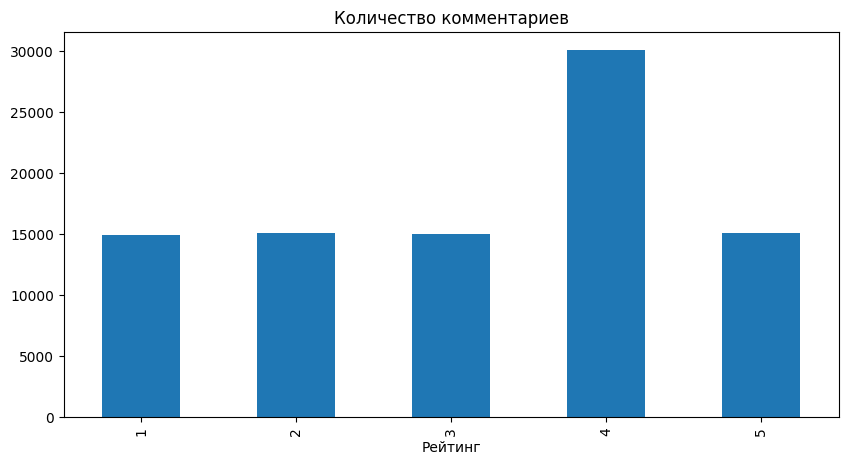

In [51]:
# 3. Количество комментариев по рейтингу


# Количество отзывов каждого рейтинга

ax = df['rating'].value_counts().sort_index() \
    .plot(kind='bar',
          title='Количество комментариев',
          figsize=(10, 5))
ax.set_xlabel('Рейтинг')
plt.show()

Вывод: больше всего отзывов имеют рейтинг 4, остальные оценки распределены равномерно.

([<matplotlib.axis.XTick at 0x1d5c0441450>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23')])

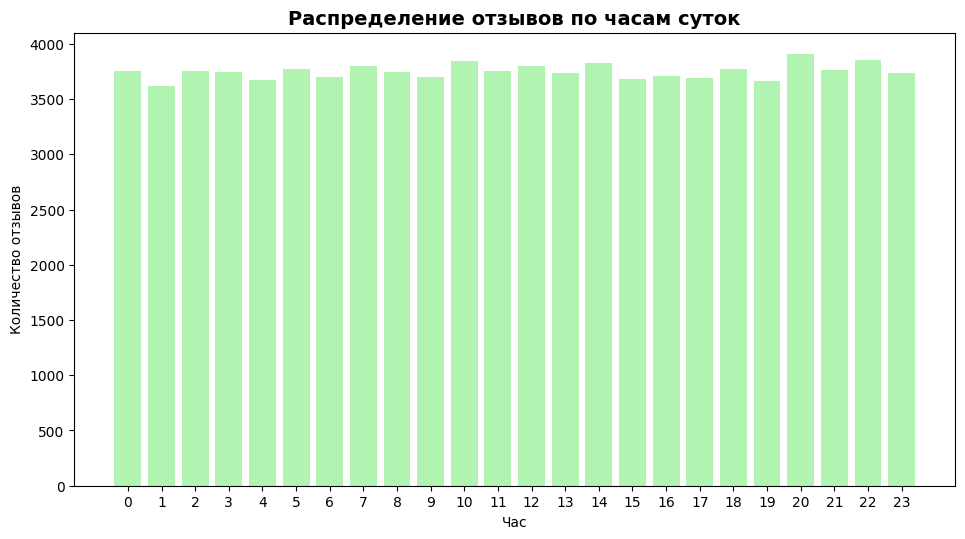

In [52]:
# 4. Распределение отзывов по часам дня
plt.figure(figsize=(25, 20))
plt.subplot(3, 2, 3)
hour_counts = df['hour'].value_counts().sort_index()
plt.bar(hour_counts.index, hour_counts.values, color='lightgreen', alpha=0.7)
plt.title('Распределение отзывов по часам суток', fontsize=14, fontweight='bold')
plt.xlabel('Час')
plt.ylabel('Количество отзывов')
plt.xticks(range(0, 24))

Вывод: отзывы практически равномерно распределены в течение дня. Наблюдается небольшой пик активности в районе 20 часов.

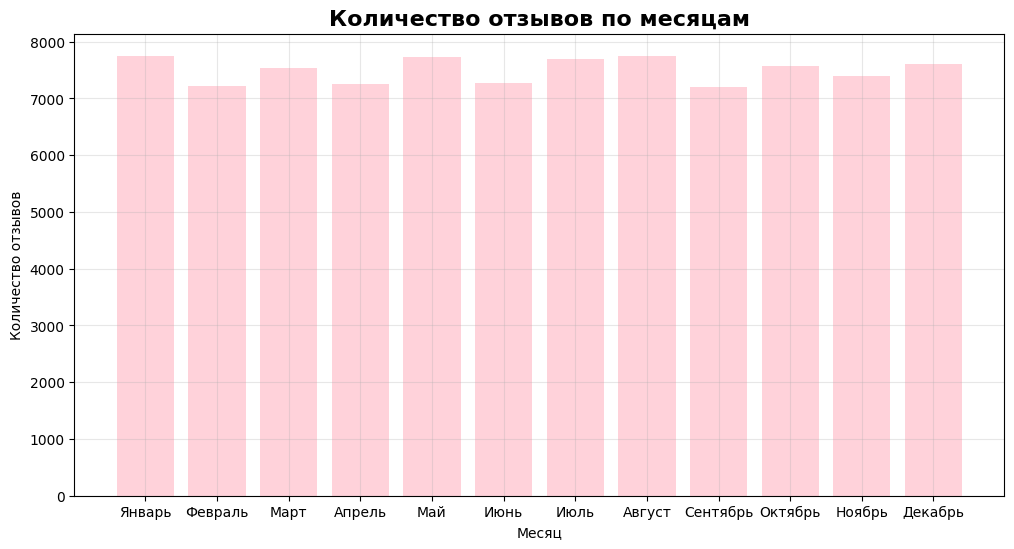

In [54]:
# 5. Количество отзывов по месяцам
plt.figure(figsize=(12, 6))
df['month'] = pd.to_datetime(df['data']).dt.month
month_counts = df['month'].value_counts().sort_index()
month_names = ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь']
plt.bar(month_counts.index, month_counts.values, color='pink', alpha=0.7)
plt.title('Количество отзывов по месяцам', fontsize=16, fontweight='bold')
plt.xlabel('Месяц')
plt.ylabel('Количество отзывов')
plt.xticks(range(1, 13), month_names)
plt.grid(True, alpha=0.3)
plt.show()

Вывод: пользователи достаточно равномерно оставляют отзывы в течение года, однако наибольшая активность наблюдается в  январе, мае, июле и августе. Возможно, это связано с бóльшим количеством свободного времени на новогодних и майских праздниках, а также в период летних отпусков.